Notebook para fazer visualizações e comparações entre distribuições CPRI e Poisson.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, errno
import sys

#Settings
BASE_DIR = 'test_poissonPG_IPACT_pred_ols'
NUMBER_OF_OLTs = 1
NUMBER_OF_ONUs = 3
DISTANCE = 20 #Distance in kilometers
TRAFFIC = "poisson"
DBA_ALG = "ipact_pred"


IPACT = {}
#load % values which represents each exponent
#loads = [25,31,37,43,50,56,62,68,75,81,87,93]
loads = [10, 30, 50, 70, 90]
#pkt arrival distribution exponents
#exponents = [1160, 1450, 1740, 2030, 2320, 2610, 2900, 3190, 3480, 3770, 4060, 4350]
exponents = [0.1, 0.3, 0.5, 0.7, 0.9]
# To do a complete test: uncomment the line below
#seeds = [20,30,40,50,60,70,80,90,100,110] #random seeds
# To do a FAST test: uncomment the line below
seeds = [20] #30, 40
#parameters = [{'w':10, 'p':3}, {'w':12, 'p':2}, {'w':15, 'p':3}, {'w':5, 'p':2}]
parameters = [{'w':12, 'p':2}, {'w':5, 'p':2}]
#parameters = [{'w':5, 'p':3}]
#parameters = [{'w':30, 'p':2}, {'w':20, 'p':2}, {'w':25, 'p':2}, {'w':15, 'p':2}]
#parameters = [{'w':30, 'p':2}, {'w':25, 'p':2}]
#PKT_SIZES = ['1536000']
#PKT_SIZES = ['768000']
PKT_SIZES = ['768000', '1536000']

for param in parameters:
    IPACT['{}-{}'.format(param['w'],param['p'])] = {}
    for payload_size in PKT_SIZES:
        IPACT['{}-{}'.format(param['w'],param['p'])][payload_size] = {}

Leitura dos dados gerados em tráfego Poisson e criação de dataframe (Alterado para lidar com múltiplas seeds e combinações de 'w' e 'p').

In [2]:
for params in parameters:    
    for payload_size in PKT_SIZES:
        for exp in exponents:
            ipact_pred = []
            for seed in seeds:
                df_tmp = pd.read_csv("{}/csv/delay/{}-dist{}-{}ONUs-{}OLTs-{}-exp{}-pkt{}-w{}-p{}-s{}-delay.csv".format(BASE_DIR, DBA_ALG, DISTANCE,
                                                                                                NUMBER_OF_ONUs, NUMBER_OF_OLTs,
                                                                                                TRAFFIC, exp, payload_size, params['w'], params['p'], seed))
                ipact_pred.append(df_tmp['delay'].mean()*1000)
            
            media = np.mean(ipact_pred)
            std = np.std(ipact_pred)
            IPACT['{}-{}'.format(params['w'], params['p'])][payload_size][exp] = [media, std]

ipact_df = pd.DataFrame(IPACT)

In [ ]:
ipact_df

Ipact básico

In [ ]:
ipact_basic = {}
for payload_size in PKT_SIZES:
    ipact_basic[payload_size] = {}
    for exp in exponents:
        aux = []
        for seed in seeds:
            df_tmp = pd.read_csv("test_poissonPG_IPACT/csv/delay/ipact-dist{}-{}ONUs-{}OLTs-{}-exp{}-pkt{}-s{}-delay.csv".format(DISTANCE,
                                                                                                                          NUMBER_OF_ONUs, NUMBER_OF_OLTs,
                                                                                                                          TRAFFIC, exp, payload_size, seed))
            aux.append(df_tmp['delay'].mean()*1000)
        media = np.mean(aux)
        std = np.std(aux)
        ipact_basic[payload_size][exp] = [media, std]
ipact_basic_df = pd.DataFrame(ipact_basic)

In [ ]:
ipact_basic_df

Abertura de figura e edição de título.

<Figure size 640x480 with 0 Axes>

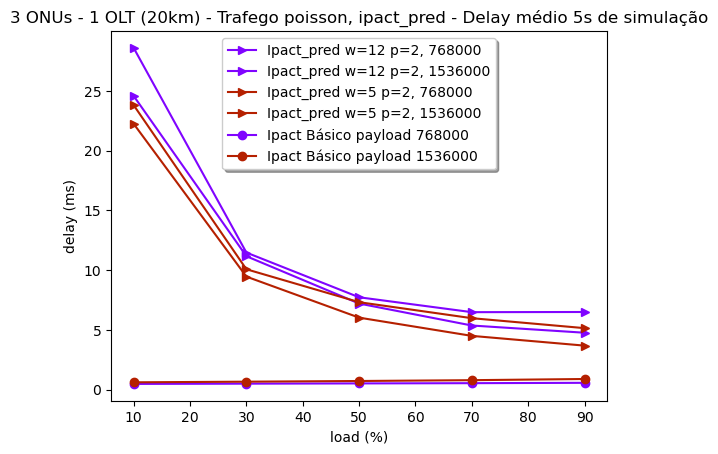

In [3]:
plt.clf()
plt.figure()
title = "{} ONUs - {} OLT ({}km) - Trafego {}, {} - Delay médio 5s de simulação".format(NUMBER_OF_ONUs, NUMBER_OF_OLTs, DISTANCE, TRAFFIC, DBA_ALG)
plt.title(title)
plt.xlabel("load (%)")
plt.ylabel("delay (ms)")
cmap = plt.get_cmap('gnuplot')
colors = [cmap(i) for i in np.linspace(0.25, 1, 4)]
#plt.errorbar(loads, ipact_df.iloc[0].values,ipact_df.iloc[1].values,color="k", linestyle='None')
#plt.plot(loads, ipact_df.iloc[0], 'o-', color="k",label="IPACT")

for j, param in enumerate(parameters):
    for payload_size in PKT_SIZES:
        aux_df = pd.DataFrame(ipact_df['{}-{}'.format(param['w'], param['p'])][payload_size])
        aux_label = 'Ipact_pred w={} p={}, {}'.format(param['w'], param['p'], payload_size)
        media_delay = np.array(aux_df.iloc[0])
        std_delay = np.array(aux_df.iloc[1])
        plt.errorbar(loads, media_delay, std_delay, color=colors[j], linestyle='None')
        plt.plot(loads, media_delay, '->', color=colors[j], label=aux_label)
i = 0
for payload_size in PKT_SIZES:
    ipact_b_aux = {}
    for exp in exponents:
        aux = []
        for seed in seeds:
            df_tmp = pd.read_csv("test_poissonPG_IPACT/csv/delay/ipact-dist{}-{}ONUs-{}OLTs-{}-exp{}-pkt{}-s{}-delay.csv".format(DISTANCE,
                                                                                                                          NUMBER_OF_ONUs, NUMBER_OF_OLTs,
                                                                                                                          TRAFFIC, exp, payload_size, seed))
            aux.append(df_tmp['delay'].mean()*1000)
        media = np.mean(aux)
        std = np.std(aux)
        ipact_b_aux[exp] = [media, std]
    aux_df = pd.DataFrame(ipact_b_aux)
    media_delay = np.array(aux_df.iloc[0])
    std_delay = np.array(aux_df.iloc[1])
    aux_label = 'Ipact Básico payload {}'.format(payload_size)
    plt.errorbar(loads, media_delay, std_delay, color='c', linestyle='None')
    plt.plot(loads, media_delay, '-o', color=colors[i], label=aux_label)
    i += 1
#plt.axhline(y=ipact_basic_df[0], color='r', linestyle='-', label='Ipact Básico')

plt.legend(loc='upper center', shadow=True)
plt.show()

Nível de ocupação (Checado através do CSV de grants)

In [4]:
GRANT_INTERVAL = {}
for param in parameters:
    GRANT_INTERVAL['{}-{}'.format(param['w'],param['p'])] = {}
    for payload_size in PKT_SIZES:
        GRANT_INTERVAL['{}-{}'.format(param['w'],param['p'])][payload_size] = {}

#CSV de grants contém tempos de start e end dos grants. Somarei o tempo utilizado por cada grant para determinação de nível de ocupação
for param in parameters:
    for payload_size in PKT_SIZES:
        for exp in exponents:
            aux = []
            for seed in seeds:
                df_tmp = pd.read_csv("{}/csv/grant_usage/{}-dist{}-{}ONUs-{}OLTs-{}-exp{}-pkt{}-w{}-p{}-s{}-grant_usage.csv".format(
                        BASE_DIR, DBA_ALG, 20, NUMBER_OF_ONUs, NUMBER_OF_OLTs, TRAFFIC, exp, payload_size, param['w'], param['p'], seed)
                )
                grant_interval = df_tmp['end'] - df_tmp['start']
                aux.append((grant_interval.sum()/5)*100)
            grant_interval_median = np.mean(aux)
            GRANT_INTERVAL['{}-{}'.format(param['w'],param['p'])][payload_size][exp] = [grant_interval_median]

intervals_df = pd.DataFrame(GRANT_INTERVAL)

In [ ]:
ipact_basic = {}
for payload_size in PKT_SIZES:
    for exp in exponents:
        aux = []
        for seed in seeds:
            df_tmp = pd.read_csv("test_poissonPG_IPACT/csv/grant_time/ipact-dist{}-{}ONUs-{}OLTs-{}-exp{}-pkt{}-s{}-grant_time.csv".format(DISTANCE,
                                                                                                                          NUMBER_OF_ONUs, NUMBER_OF_OLTs,
                                                                                                                          TRAFFIC, exp, payload_size, seed))
            grant_interval = df_tmp['end'] - df_tmp['start']
            aux.append((grant_interval.sum()/5)*100)

    ipact_basic[exp] = [np.mean(aux)]
ipact_basic_df = pd.DataFrame(ipact_basic)

Geração de gráfico

[ 3.045888  9.34044  15.228072 19.8912   22.826808]
[ 3.167448  9.590904 15.30024  20.0862   25.077504]


<Figure size 640x480 with 0 Axes>

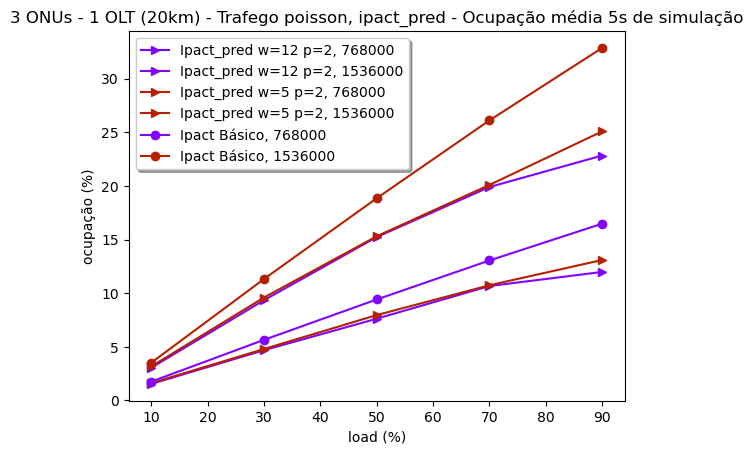

In [5]:
plt.clf()
plt.figure()
title = "{} ONUs - {} OLT ({}km) - Trafego {}, {} - Ocupação média 5s de simulação".format(NUMBER_OF_ONUs, NUMBER_OF_OLTs, DISTANCE, TRAFFIC, DBA_ALG)
plt.title(title)
plt.xlabel("load (%)")
plt.ylabel("ocupação (%)")
cmap = plt.get_cmap('gnuplot')
colors = [cmap(i) for i in np.linspace(0.25, 1, 4)]
#plt.errorbar(loads, ipact_df.iloc[0].values,ipact_df.iloc[1].values,color="k", linestyle='None')
#plt.plot(loads, ipact_df.iloc[0], 'o-', color="k",label="IPACT")

for j, param in enumerate(parameters):
    for payload_size in PKT_SIZES:
        aux_df = pd.DataFrame(intervals_df['{}-{}'.format(param['w'], param['p'])][payload_size])
        aux_label = 'Ipact_pred w={} p={}, {}'.format(param['w'], param['p'], payload_size)
        array_aux = np.array(aux_df.iloc[0])
    #print(array_aux)
    #plt.errorbar(loads, array_aux[:,0], array_aux[:,1], color=colors[j], linestyle='None')
        plt.plot(loads, array_aux, '->', color=colors[j], label=aux_label)
    print(array_aux)

i = 0
for payload_size in PKT_SIZES:
    ipact_basic = {}
    for exp in exponents:
        aux = []
        for seed in seeds:
            df_tmp = pd.read_csv("test_poissonPG_IPACT/csv/grant_usage/ipact-dist{}-{}ONUs-{}OLTs-{}-exp{}-pkt{}-s{}-grant_usage.csv".format(DISTANCE,
                                                                                                                          NUMBER_OF_ONUs, NUMBER_OF_OLTs,
                                                                                                                          TRAFFIC, exp, payload_size, seed))
            grant_interval = df_tmp['end'] - df_tmp['start']
            aux.append((grant_interval.sum()/5)*100)

        ipact_basic[exp] = [np.mean(aux)]
    ipact_basic_df = pd.DataFrame(ipact_basic)


    array_aux = np.array(ipact_basic_df)
    aux_label = 'Ipact Básico, {}'.format(payload_size)
    plt.plot(loads, array_aux[0], '-o', color=colors[i], label=aux_label)
    i += 1
#plt.axhline(y=df_tmp[0][0], color='r', linestyle='-', label='CPRI-1')

plt.legend(loc='best', shadow=True)
plt.show()

Banda oferecida

In [ ]:
DATA_SENT = {}
for param in parameters:
    DATA_SENT['{}-{}'.format(param['w'],param['p'])] = {}
    for payload_size in PKT_SIZES:
        DATA_SENT['{}-{}'.format(param['w'],param['p'])][payload_size] = {}

#CSV de grants contém tempos de start e end dos grants. Somarei o tempo utilizado por cada grant para determinação de nível de ocupação
for param in parameters:
    for payload_size in PKT_SIZES:
        for exp in exponents:
            aux = []
            for seed in seeds:
                df_tmp = pd.read_csv("{}/csv/grant_usage/{}-dist{}-{}ONUs-{}OLTs-{}-exp{}-pkt{}-w{}-p{}-s{}-grant_usage.csv".format(
                        BASE_DIR, DBA_ALG, 20, NUMBER_OF_ONUs, NUMBER_OF_OLTs, TRAFFIC, exp, payload_size, param['w'], param['p'], seed)
                )
                total_data = df_tmp['data sent'].sum() #total de dados enviados, em bytes
                total_data = total_data/(1024*1024) #conversão para Mega-bytes
                aux.append(total_data/5) #lista auxiliar recebe carga total de dados/tempo de simulação
            bandwidth_median = np.mean(aux)
            DATA_SENT['{}-{}'.format(param['w'],param['p'])][payload_size][exp] = [bandwidth_median]

bandwidth_df = pd.DataFrame(DATA_SENT)

In [ ]:
plt.clf()
plt.figure()
title = "{} ONUs - {} OLT ({}km) - Trafego {}, {} - Bandwidth média 5s de simulação".format(NUMBER_OF_ONUs, NUMBER_OF_OLTs, DISTANCE, TRAFFIC, DBA_ALG)
plt.title(title)
plt.xlabel("load (%)")
plt.ylabel("ocupação (%)")
cmap = plt.get_cmap('gnuplot')
colors = [cmap(i) for i in np.linspace(0.25, 1, 4)]
#plt.errorbar(loads, ipact_df.iloc[0].values,ipact_df.iloc[1].values,color="k", linestyle='None')
#plt.plot(loads, ipact_df.iloc[0], 'o-', color="k",label="IPACT")

for j, param in enumerate(parameters):
    for payload_size in PKT_SIZES:
        aux_df = pd.DataFrame(bandwidth_df['{}-{}'.format(param['w'], param['p'])][payload_size])
        aux_label = 'Ipact_pred w={} p={}, {}'.format(param['w'], param['p'], payload_size)
        array_aux = np.array(aux_df.iloc[0])
    #print(array_aux)
    #plt.errorbar(loads, array_aux[:,0], array_aux[:,1], color=colors[j], linestyle='None')
        plt.plot(loads, array_aux, '->', color=colors[j], label=aux_label)
    print(array_aux)

i = 0
for payload_size in PKT_SIZES:
    ipact_basic = {}
    for exp in exponents:
        aux = []
        for seed in seeds:
            df_tmp = pd.read_csv("test_poissonPG_IPACT/csv/grant_usage/ipact-dist{}-{}ONUs-{}OLTs-{}-exp{}-pkt{}-s{}-grant_usage.csv".format(DISTANCE,
                                                                                                                          NUMBER_OF_ONUs, NUMBER_OF_OLTs,
                                                                                                                          TRAFFIC, exp, payload_size, seed))
            grant_interval = df_tmp['end'] - df_tmp['start']
            aux.append((grant_interval.sum()/5)*100)

        ipact_basic[exp] = [np.mean(aux)]
    ipact_basic_df = pd.DataFrame(ipact_basic)


    array_aux = np.array(ipact_basic_df)
    aux_label = 'Ipact Básico, {}'.format(payload_size)
    plt.plot(loads, array_aux[0], '-o', color=colors[i], label=aux_label)
    i += 1
#plt.axhline(y=df_tmp[0][0], color='r', linestyle='-', label='CPRI-1')

plt.legend(loc='best', shadow=True)
plt.show()